In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langgraph.prebuilt import ToolRuntime
from utils import model_untils


C:\soft\anaconda3\envs\ai80\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
def dynamic_model_selection_demo(query:str):
    """
    根据对话复杂性动态选择模型

    核心思路：
      - 简单问题 / 短对话 → 使用轻量模型（本地 Ollama），速度快、成本低
      - 复杂问题 / 长对话 → 使用高级模型（云端 Qwen），能力更强

    通过 middleware（中间件）机制，在每次模型调用前自动判断并切换模型
    """

    from langchain_core.tools import tool

    # 定义工具
    @tool
    def get_weather(location: str, runtime: ToolRuntime) -> str:
        """获取指定位置的天气信息。"""
        weather_db = {
            "北京": "晴，25°C",
            "上海": "多云，28°C",
            "广州": "小雨，30°C",
            "深圳": "晴，29°C",
        }
        print(f"get_weather:{runtime.state.get('messages')}")
        return weather_db.get(location, f"{location} 的天气：暂无数据")

    @tool
    def calculator(expression: str) -> str:
        """计算数学表达式的结果。"""
        try:
            return f"计算结果：{eval(expression)}"
        except Exception as e:
            return f"计算错误：{e}"

    # -------------------------------------------------------------------------
    # 准备两个模型：基础模型 + 高级模型
    # -------------------------------------------------------------------------
    basic_model = ChatOllama(model="qwen3.5:2b")           # 本地轻量模型
    advanced_model = model_untils.get_qwen_client()        # 云端高级模型

    if advanced_model is None:
        print("【跳过】未配置阿里云 API Key，无法运行此示例")
        return

    # 用于跨 invoke 累积消息数（闭包状态）
    total_messages = [0]

    # -------------------------------------------------------------------------
    # 定义中间件：根据消息数量动态选择模型
    # -------------------------------------------------------------------------
    @wrap_model_call
    def dynamic_model_selection(runtime: ToolRuntime, handler) -> ModelResponse:
        """根据对话复杂性选择模型。
        可以自定义策略（可以使用指定的关键字判断，也可以使用模型判断）

        策略：
          - 累积消息数 > 10 → 切换到高级模型（长对话需要更强的推理能力）
          - 累积消息数 ≤ 10 → 使用基础模型（简单任务不需要大模型）
        """
        # 累加当前请求的消息数（每次 invoke 的消息会持续增加）
        # total_messages[0] += len(runtime.messages)
        # msg_count = total_messages[0]

        msg_count = sum(len(msg.content) for msg in runtime.messages)
        if msg_count > 100:
            # 对较长的对话使用高级模型（使用 override API 替代已废弃的直接赋值）
            print(f"  [动态切换] 累积消息数={msg_count} -> 使用高级模型 (Qwen)")
            return handler(runtime.override(model=advanced_model))
        else:
            print(f"  [动态切换] 累积消息数={msg_count} -> 使用基础模型 (Ollama)")
            return handler(runtime)

    # -------------------------------------------------------------------------
    # 创建带中间件的 Agent
    # -------------------------------------------------------------------------
    agent = create_agent(
        model=basic_model,                        # 默认模型
        tools=[get_weather, calculator],
        middleware=[dynamic_model_selection]       # 注入动态选择中间件
    )


    result = agent.invoke(
        {"messages": [{"role": "user", "content": query}]}
    )

    return result["messages"][-1].content

In [3]:
dynamic_model_selection_demo("我是Luke，很高兴认识你")

  [动态切换] 累积消息数=13 -> 使用基础模型 (Ollama)


'你好Luke！很高兴认识你。那么今天我们可以聊聊什么吗？或者有任何我可以帮助你的吗？'

In [4]:
dynamic_model_selection_demo("深圳今天天气怎么样？")

  [动态切换] 累积消息数=10 -> 使用基础模型 (Ollama)
get_weather:[HumanMessage(content='深圳今天天气怎么样？', additional_kwargs={}, response_metadata={}, id='11c49203-7611-4612-ac7e-ecc41c16080e'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5:2b', 'created_at': '2026-05-05T12:32:04.3746283Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1052281400, 'load_duration': 142568400, 'prompt_eval_count': 329, 'prompt_eval_duration': 204859000, 'eval_count': 58, 'eval_duration': 670028200, 'logprobs': None, 'model_name': 'qwen3.5:2b', 'model_provider': 'ollama'}, id='lc_run--019df81f-bef9-7bc0-a61f-b05d3870cbf9-0', tool_calls=[{'name': 'get_weather', 'args': {'location': '深圳'}, 'id': 'd3e4f314-8bcd-4fe6-8306-e5e31666314b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 329, 'output_tokens': 58, 'total_tokens': 387})]
  [动态切换] 累积消息数=16 -> 使用基础模型 (Ollama)


'深圳今天天气晴朗，气温为29°C。'

In [6]:
query = """
是物理学中研究微观粒子（如电子、光子等）行为的物理理论体系，它揭示了自然界在原子和亚原子层面的基本规律。\n\n## 核心原理\n\n### 1. **波粒二象性**\n量子粒子同时具有粒子和波的特性，无法用经典粒子或经典波的概念来完全描述。\n\n### 2. **不确定性原理**\n海森堡不确定性原理指出：我们无法同时精确知道一个粒子的位置和动量，存在一个理论上的最小极限：\n\n$$ \\Delta x \\cdot \\Delta p \\geq \\frac{h}{4\\pi} $$\n\n这意味着量子态和叠加**\n量子系统可以被描述为量子态，系统可以同时处于多个状态，直到被观测。\n\n### 4. **量子纠缠**\n量子纠缠是物理学中一个非常奇特的现象：两个或多个粒子相互关联，无论它们相隔多远，对一个粒子的测量会立即影响另一个粒子的状态。\n\n### 5. **量子隧穿效应**\n粒子可以穿过能量壁垒，在经典物理中不可能发生的现象位
"""
dynamic_model_selection_demo(query)

  [动态切换] 累积消息数=409 -> 使用高级模型 (Qwen)


'您描述的是**量子力学**（Quantum Mechanics），它是20世纪初发展起来的、描述微观粒子（如电子、质子、光子、中子等）运动规律的基础物理理论，与经典力学、电磁学、热力学并列为现代物理学的四大支柱之一。\n\n您列出的核心原理非常准确，下面我为您简要梳理并补全（特别是第3点和第5点中略有缺漏的文字），并稍作延伸说明：\n\n---\n\n### ✅ 1. 波粒二象性  \n- 德布罗意提出：所有物质都具有波动性，波长 $\\lambda = \\frac{h}{p}$（德布罗意关系）。  \n- 实验验证：电子衍射（戴维森-革末实验）、双缝干涉（单电子也能产生干涉图样）。\n\n### ✅ 2. 不确定性原理（Heisenberg, 1927）  \n- 不是测量技术限制，而是自然界的根本属性：  \n  $$\\Delta x \\cdot \\Delta p_x \\ge \\frac{\\hbar}{2},\\quad \\Delta E \\cdot \\Delta t \\ge \\frac{\\hbar}{2}$$  \n  （其中 $\\hbar = h/2\\pi$ 是约化普朗克常量）\n\n### ✅ 3. 量子态与叠加原理（补全）  \n- 量子系统状态由**态矢量**（如波函数 $\\psi(x,t)$）描述，满足薛定谔方程；  \n- 若 $|\\psi_1\\rangle$ 和 $|\\psi_2\\rangle$ 是可能的状态，则其线性叠加 $c_1|\\psi_1\\rangle + c_2|\\psi_2\\rangle$ 也是合法量子态；  \n- 观测导致**波函数坍缩**——系统“随机”塌缩到某个本征态，概率由 $|c_i|^2$ 给出（玻恩规则）。\n\n### ✅ 4. 量子纠缠  \n- 多粒子系统的态不可分解为各子系统态的直积（如贝尔态 $|\\Phi^+\\rangle = \\frac{1}{\\sqrt{2}}(|00\\rangle + |11\\rangle)$）；  \n- 实验已多次验证违背贝尔不等式（如阿斯佩实验、2022年诺贝尔物理学奖成果），证实非局域关联真实存在。\n\n### ✅ 5. 量子隧穿效应（补全）  \n- 粒子有一定概率穿过**高于其自身能量的势垒**（如α衰变、扫描隧

In [ ]:
while True:
    query = input("请输入问题：")
    if query == "exit":
        break
    result = dynamic_model_selection_demo(query)
    print(f"回答：{result}")

In [15]:
def simple_two_node_graph():
    """
    最简单的 LangGraph：两个节点顺序执行

    START → 问候 → 回应 → END
    """
    print("=" * 60)
    print("示例 1: 最简图 - 两个节点顺序执行")
    print("=" * 60)

    from typing import TypedDict
    from langgraph.graph import StateGraph, START, END

    # 1. 定义状态：图中传递的数据结构
    #    TypedDict 是 Python 的类型提示工具，LangGraph 用它来定义"贯穿整张图的状态"
    #    每个节点函数都可以读取和修改这个状态
    class GraphState(TypedDict):
        """图的状态：存储消息和步骤计数"""
        messages: list[str]
        step_count: int

    # 2. 定义节点函数：每个节点接收状态，返回状态更新
    #    ⚠️ 关键：节点函数的返回值不是"替换"整个状态，而是"合并"到状态中
    #    例如 return {"messages": [...]} 只会更新 messages 字段，step_count 不受影响
    def greet(state: GraphState):
        """节点 1：添加问候消息"""
        print("  [节点: greet] 添加问候语")
        return {
            "messages": ["你好！很高兴见到你！"],
            "step_count": 1
        }

    def respond(state: GraphState):
        """节点 2：添加回应消息
        这里演示了如何读取之前的状态（state["step_count"]）并在此基础上更新
        """
        print("  [节点: respond] 添加回应")
        return {
            "messages": ["你好！我也很高兴！"],
            "step_count": state["step_count"] + 1  # 读取上一步的值，+1
        }

    # 3. 构建图：连接节点
    #    StateGraph(GraphState)  — 创建一个带状态的图，状态类型是 GraphState
    #    .add_node("名字", 函数)  — 注册一个节点，"名字" 用于后续连线时引用
    #    .add_edge(A, B)         — 添加一条从 A 到 B 的固定边（无条件，一定执行）
    #    START                   — 图的入口常量，等价于"从这里开始"
    #    END                     — 图的出口常量，等价到这里结束
    #    .compile()              — 把图编译成可执行的对象
    graph = (
        StateGraph(GraphState)
        .add_node("greet", greet)       # 添加节点
        .add_node("respond", respond)
        .add_edge(START, "greet")       # 起点 → greet
        .add_edge("greet", "respond")   # greet → respond
        .add_edge("respond", END)       # respond → 终点
        .compile()
    )


    from IPython.display import Image, display
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

    # 4. 执行图
    #    invoke() 的参数是初始状态，图会从这个初始状态开始按边依次执行节点
    #    返回值是最终的状态（所有节点执行完毕后的状态）
    print("【执行图】")
    result = graph.invoke({"messages": [], "step_count": 0})
    print(f"  最终消息: {result['messages']}")
    print(f"  总步骤数: {result['step_count']}")
    print()

示例 1: 最简图 - 两个节点顺序执行


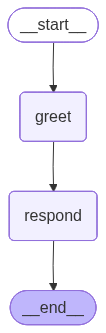

【执行图】
  [节点: greet] 添加问候语
  [节点: respond] 添加回应
  最终消息: ['你好！我也很高兴！']
  总步骤数: 2



In [16]:
simple_two_node_graph()